# **Trabajo Práctico Final - Computer Vision**
## Tecnicatura Universitaria en Inteligencia Artificial
### Integrantes:
-  Sancho Almenar, Mariano S-5778/9



## Objetivo General

Desarrollar un pipeline completo de visión por computadora para la identificación de razas de perros en imágenes. El proyecto abarca desde la creación de un sistema de búsqueda por similitud hasta la implementación de un sistema de detección y clasificación en imágenes complejas, incluyendo el entrenamiento y la optimización de modelos de Deep Learning.

# Preparación de Entorno

In [1]:
# !pip install -q gdown
#!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118
# Acordarse de agregar apt-get update && apt-get install -y libgl1 para que ande yolo

In [2]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install faiss-cpu
    !pip install ultralytics>=8.0.0
    !pip install -q gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 68.9 MB/s eta 0:00:00


In [3]:
import os
import numpy as np
import zipfile
import gdown
import random
from collections import defaultdict, Counter
import faiss
import gradio as gr
from tqdm import tqdm
import tempfile
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from functools import partial
from pathlib import Path
import plotly.graph_objects as go
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
from ultralytics import YOLO
import json

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
os.makedirs('outputs/plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Descarga y Preparación del Dataset

## Descarga y unzip

In [58]:
!gdown --fuzzy "https://drive.google.com/file/d/12mrHUvn2hhQzokLRgSQKjvQbd6XjXc7C/view?usp=sharing" -O dataset.zip

with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
    zip_ref.extractall("data/")

Downloading...
From (original): https://drive.google.com/uc?id=12mrHUvn2hhQzokLRgSQKjvQbd6XjXc7C
From (redirected): https://drive.google.com/uc?id=12mrHUvn2hhQzokLRgSQKjvQbd6XjXc7C&confirm=t&uuid=973f125e-4289-4118-9ece-ea9657a77993
To: /content/datasett.zip
100% 227M/227M [00:03<00:00, 58.5MB/s]


## Preparación del Dataset

In [6]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# Para entrenamiento (con data augmentation)
train_transform = transforms.Compose([
    # transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    # transforms.RandomRotation(20),
    # transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Para validación y test (sin aumentos)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Cargar datasets
trainset = datasets.ImageFolder(root='./data/train', transform=train_transform)
validset = datasets.ImageFolder(root='./data/valid', transform=test_transform)
testset  = datasets.ImageFolder(root='./data/test',  transform=test_transform)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
validloader = DataLoader(validset, batch_size=BATCH_SIZE, shuffle=False)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
print(f"Cantidad de imágenes en el set de entrenamiento: {len(trainset)}")
print(f"Cantidad de imágenes en el set de validación: {len(validset)}")
print(f"Cantidad de imágenes en el set de test: {len(testset)}")

Cantidad de imágenes en el set de entrenamiento: 7946
Cantidad de imágenes en el set de validación: 700
Cantidad de imágenes en el set de test: 700


## EDA

### Cantidad de Clases

In [8]:
class_names = trainset.classes
num_classes = len(class_names)
print(f"El dataset cuenta con un total de {num_classes} clases")
print(class_names)


El dataset cuenta con un total de 70 clases
['Afghan', 'African Wild Dog', 'Airedale', 'American Hairless', 'American Spaniel', 'Basenji', 'Basset', 'Beagle', 'Bearded Collie', 'Bermaise', 'Bichon Frise', 'Blenheim', 'Bloodhound', 'Bluetick', 'Border Collie', 'Borzoi', 'Boston Terrier', 'Boxer', 'Bull Mastiff', 'Bull Terrier', 'Bulldog', 'Cairn', 'Chihuahua', 'Chinese Crested', 'Chow', 'Clumber', 'Cockapoo', 'Cocker', 'Collie', 'Corgi', 'Coyote', 'Dalmation', 'Dhole', 'Dingo', 'Doberman', 'Elk Hound', 'French Bulldog', 'German Sheperd', 'Golden Retriever', 'Great Dane', 'Great Perenees', 'Greyhound', 'Groenendael', 'Irish Spaniel', 'Irish Wolfhound', 'Japanese Spaniel', 'Komondor', 'Labradoodle', 'Labrador', 'Lhasa', 'Malinois', 'Maltese', 'Mex Hairless', 'Newfoundland', 'Pekinese', 'Pit Bull', 'Pomeranian', 'Poodle', 'Pug', 'Rhodesian', 'Rottweiler', 'Saint Bernard', 'Schnauzer', 'Scotch Terrier', 'Shar_Pei', 'Shiba Inu', 'Shih-Tzu', 'Siberian Husky', 'Vizsla', 'Yorkie']


### Distribución de imágenes por clase

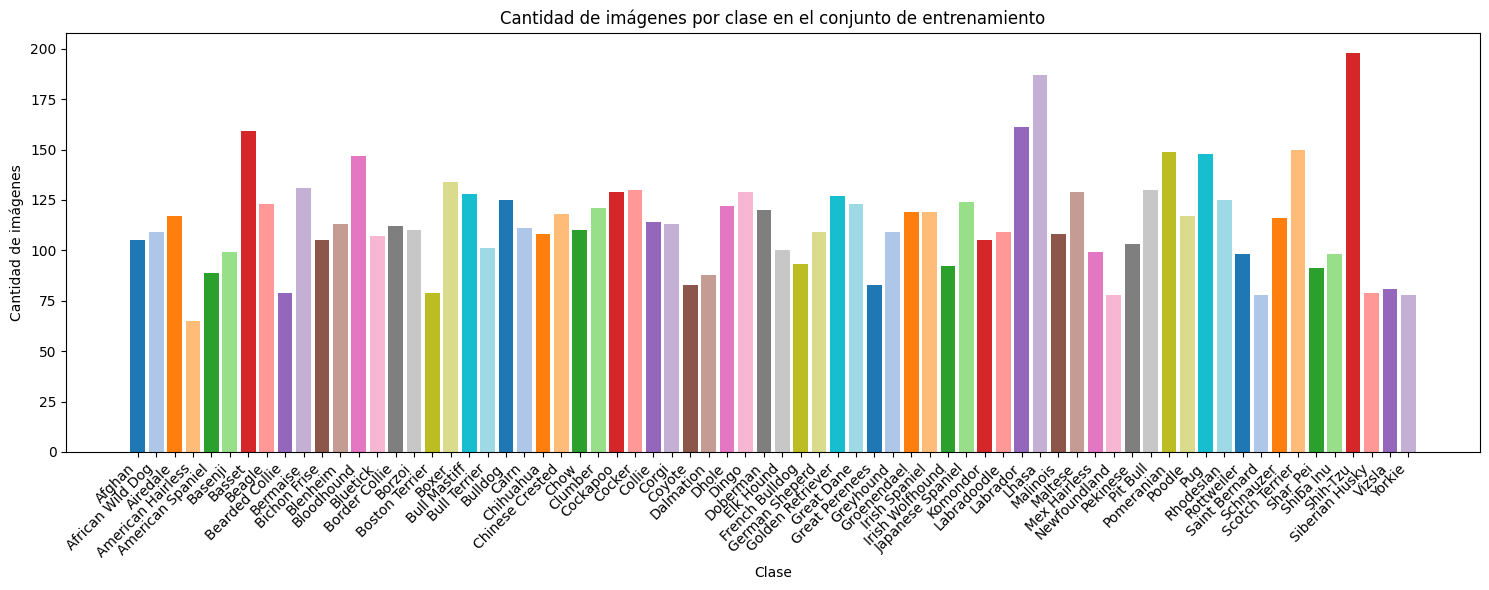

In [9]:
# Contar cuántas imágenes hay por clase
class_counts = Counter(trainset.targets)

counts_array = np.array([class_counts[i] for i in range(len(class_names))])

# Gráfico
plt.figure(figsize=(15, 6))
bars = plt.bar(class_names, counts_array, color=plt.cm.tab20.colors[:len(class_names)])

plt.xlabel('Clase')
plt.ylabel('Cantidad de imágenes')
plt.title('Cantidad de imágenes por clase en el conjunto de entrenamiento')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/plots/class_distribution.png')
plt.show()

Se observa que no hay un gran balanceo entre clases. Siendo 'Shih-Tzu' la clase con mayor cantidad de imágenes (198) y 'American Hairless' con menor cantidad (68)

### Visualización de algunas imágenes

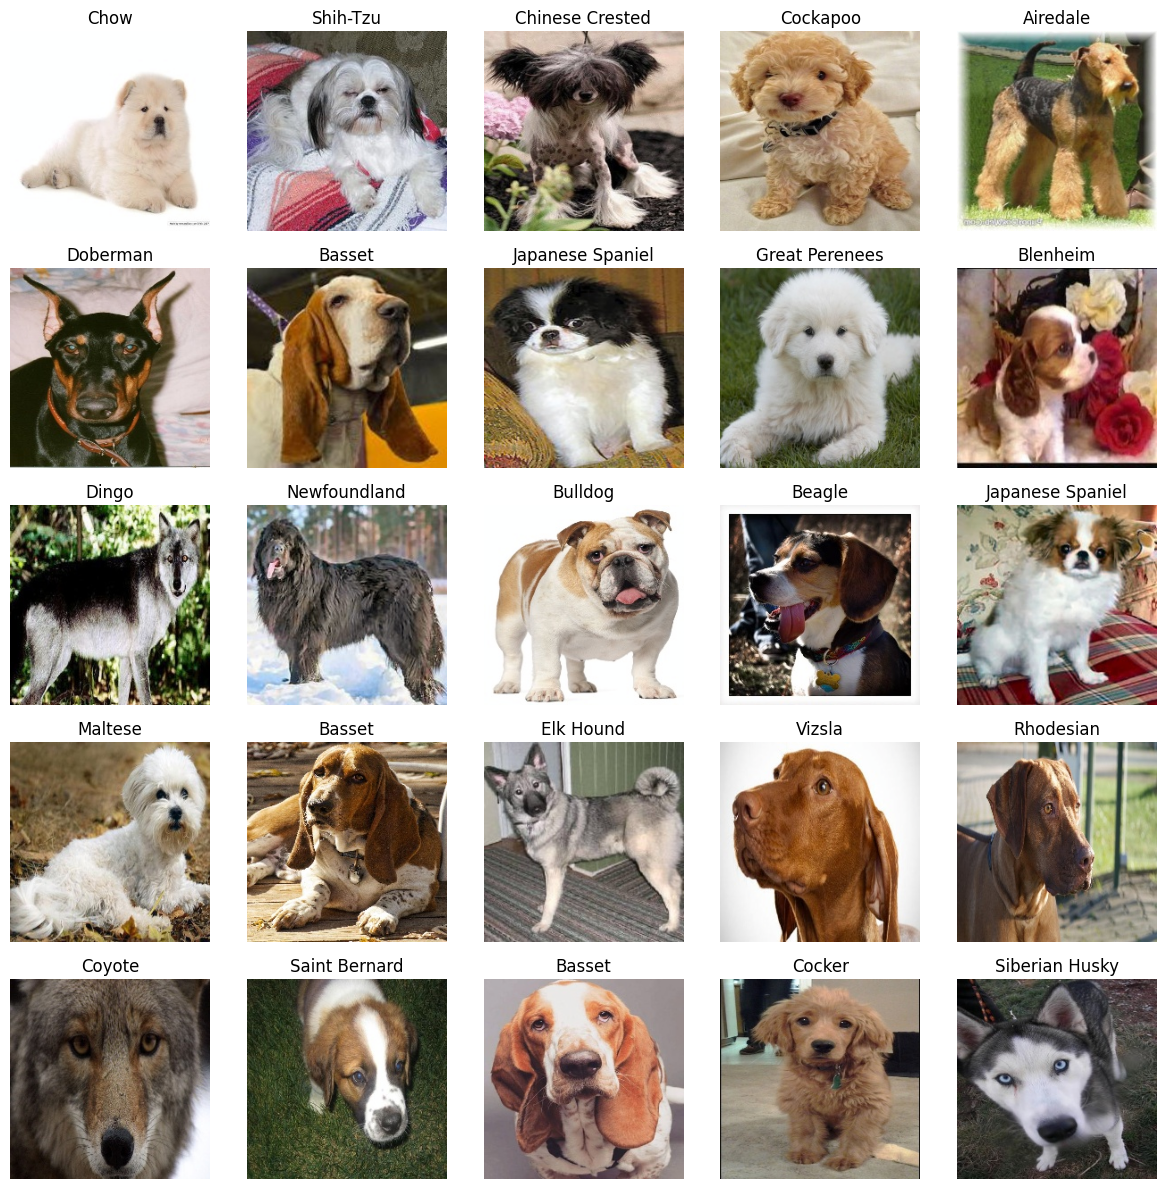

In [10]:
plt.figure(figsize=(12, 12))

# Obtener una sola tanda (batch) del DataLoader
images, labels = next(iter(trainloader))


for i in range(25):
    ax = plt.subplot(5, 5, i + 1)

    # Desnormalizar imagen (ImageNet)
    img = images[i].numpy().transpose((1, 2, 0))  # CHW -> HWC
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(trainset.classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.savefig('outputs/plots/images_examples.png')
plt.show()

# **Etapa 1**:  Buscador de Imágenes por Similitud

## Creación de la Base de Datos Vectorial


In [11]:
def prepare_faiss_index(dataloader, model, device, class_names):
    all_features = []
    image_paths = []
    image_labels = []

    temp_dir = tempfile.mkdtemp()
    model.eval()

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(dataloader):
            images = images.to(device)

            features = model(images).squeeze(-1).squeeze(-1).cpu().numpy()
            all_features.append(features)

            for img_idx, (img_tensor, label) in enumerate(zip(images.cpu(), labels)):
                # Desnormalizar la imagen para guardarla
                img_array = img_tensor.numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img_array = std * img_array + mean  # Desnormalizar
                img_array = (img_array * 255).clip(0, 255).astype("uint8")

                # Convertir a imagen RGB
                if img_array.shape[2] == 1:
                    img_array = np.repeat(img_array, 3, axis=2)

                img_pil = Image.fromarray(img_array)
                path = os.path.join(temp_dir, f"resnet_b{batch_idx}_i{img_idx}.jpg")
                img_pil.save(path)

                image_paths.append(path)
                image_labels.append(class_names[label.item()])

    all_features = np.concatenate(all_features, axis=0).astype("float32")
    index = faiss.IndexFlatL2(all_features.shape[1])
    index.add(all_features)

    return index, image_paths, image_labels


In [12]:
# Importo Modelo ResNet50 pre-entrenado
rn50_model =  models.resnet50(pretrained=True)

# Eliminar la última capa fully-connected (la de clasificación)
rn50_model = torch.nn.Sequential(*(list(rn50_model.children())[:-1]))

# Congelar todos los parámetros
for param in rn50_model.parameters():
    param.requires_grad_(False)

rn50_model = rn50_model.to(device)
rn50_model.eval();

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 75.3MB/s]


In [13]:
# Creación Base Vectorial
index, image_paths, image_labels = prepare_faiss_index(trainloader, rn50_model, device, class_names)

## Clasificación Basada en Similitud y Métrica de Evaluación

### Búsqueda de imágenes similares


In [14]:
def find_similar_images(img_input, model, index, image_paths, image_labels, device, k=10):

    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img = transform(img_input)

    # Mover a dispositivo y añadir dimensión de batch si es necesario
    img = img.to(device)
    if img.dim() == 3:
        img = img.unsqueeze(0)

    model.eval()

    with torch.no_grad():
        features = model(img).squeeze(-1).squeeze(-1).cpu().numpy().astype("float32")

    distances, indices = index.search(features, k)

    similar_images = [(image_paths[i], image_labels[i], float(distances[0][j]))
                    for j, i in enumerate(indices[0])]

    breeds = [label for _, label, _ in similar_images]
    predicted_breed = Counter(breeds).most_common(1)[0][0]

    return similar_images, predicted_breed

### NDCG

In [15]:
def select_test_subset(dataset, class_names, k=5):
    """
    Selecciona aleatoriamente k imágenes por clase del dataset
    Args:
        dataset: PyTorch Dataset (como testset)
        class_names: Lista de nombres de clases
        k: Número de imágenes por clase a seleccionar
    """
    class_to_images = defaultdict(list)

    # Iterar sobre el dataset completo
    for idx in range(len(dataset)):
        img_tensor, class_idx = dataset[idx]
        class_name = class_names[class_idx]
        class_to_images[class_name].append((img_tensor, class_name))

    # Seleccionar k imágenes por clase
    test_subset = []
    for class_name, samples in class_to_images.items():
        selected = random.sample(samples, k=min(len(samples), k))
        test_subset.extend(selected)

    print(f"Total de imágenes seleccionadas: {len(test_subset)}")
    return test_subset

def tensor_to_pil(img_tensor):
    """Convierte tensor PyTorch a PIL Image"""
    # 1. Convertir tensor a numpy y reordenar dimensiones
    img_array = img_tensor.numpy().transpose((1, 2, 0))

    # 2. Desnormalizar (usando los parámetros de ImageNet)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_array = std * img_array + mean

    # 3. Escalar a [0, 255] y convertir a uint8
    img_array = (img_array * 255).clip(0, 255).astype("uint8")

    # 4. Convertir a PIL Image
    return Image.fromarray(img_array)

def ndcg_at_k(true_label, pred_labels, k=10):
    """Calcula NDCG@k para una consulta"""
    relevances = [1 if label == true_label else 0 for label in pred_labels[:k]]
    dcg = sum([rel / np.log2(i + 2) for i, rel in enumerate(relevances)])
    idcg = sum([1 / np.log2(i + 2) for i in range(min(k, sum(relevances)))])
    return dcg / idcg if idcg > 0 else 0

In [16]:
test_subset = select_test_subset(testset, class_names, k=6)

# 3. Calcular NDCG para cada imagen
ndcg_scores = []

for img_tensor, true_label in test_subset:
    # Convertir tensor a PIL Image
    img_pil = tensor_to_pil(img_tensor)

    # Buscar imágenes similares
    similar_images, _ = find_similar_images(
        img_pil, rn50_model, index, image_paths, image_labels, device, k=10
    )

    # Obtener etiquetas de los resultados
    retrieved_labels = [label for _, label, _ in similar_images]

    # Calcular NDCG
    score = ndcg_at_k(true_label, retrieved_labels, k=10)
    ndcg_scores.append(score)

# 4. Calcular métricas finales
average_ndcg = np.mean(ndcg_scores)
std_ndcg = np.std(ndcg_scores)

print(f"NDCG@10 promedio: {average_ndcg:.4f} ± {std_ndcg:.4f}")

Total de imágenes seleccionadas: 420
NDCG@10 promedio: 0.9708 ± 0.0952


## Interfaz de Gradio

In [17]:
!pip install --upgrade gradio fastapi starlette --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.3/54.3 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.9/323.9 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.5/95.5 kB 9.5 MB/s eta 0:00:00


In [18]:
def gradio_interface(img_input, average_ndcg):
    similar_images, predicted_breed = find_similar_images(
        img_input, rn50_model, index, image_paths, image_labels, device, k=10
    )

    # Usa PIL para que Gradio los muestre correctamente
    output_imgs = [Image.open(img_path) for img_path, _, _ in similar_images]

    ndcg_text = round(average_ndcg, 2)
    return output_imgs, predicted_breed, ndcg_text

iface = gr.Interface(
    fn=partial(gradio_interface, average_ndcg=average_ndcg),
    inputs=gr.Image(type="pil", label="Sube una imagen de perro"),
    outputs=[
        gr.Gallery(label="Imágenes más similares", columns=5),
        gr.Textbox(label="Predicción de raza por mayoría"),
        gr.Textbox(label="NDCG@10 promedio sobre subconjunto de prueba")
    ],
    title="Buscador de similitud y clasificación de razas de perros",
    description="Sube una imagen de perro para encontrar imágenes similares y predecir su raza."
)

iface.launch()

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f10eac8e79969a24d0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# **Etapa 2**: Entrenamiento y Comparación de modelos de Clasificación

## Definición de funciones y clases

In [19]:
# Se crea la Clase History para almacenar los historiales de entrenamiento
# en los modelos para luego realizar la gráfica de entrenamiento

class History:
    def __init__(self):
        self.history = {
            'accuracy': [],
            'val_accuracy': [],
            'loss': [],
            'val_loss': []
        }

In [87]:
def acc_loss_plot(model_history: History, save_name = None) -> None:
    """
    Función para graficar accuracy y loss para train y validación.

    Args:
        model_history: Historia de entrenamiento del modelo.
    """
    os.makedirs("outputs", exist_ok=True)
    plt.figure(figsize=(10, 8))

    # Accuracy
    plt.subplot(2, 2, 1)
    plt.title("Accuracy Train/Validación con respecto a las épocas")
    plt.plot(model_history.history['accuracy'], label='Train Accuracy')
    plt.plot(model_history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.legend(loc='lower right')

    # Loss
    plt.subplot(2, 2, 2)
    plt.title("Loss Train/Validación con respecto a las épocas")
    plt.plot(model_history.history['loss'], label='Train Loss')
    plt.plot(model_history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.ylim([0, 3])
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.savefig(f"outputs/plots/{save_name}_acc_loss_plot.png")
    plt.show()

In [21]:
def train_model(model, trainloader, validloader, criterion, optimizer, scheduler, num_epochs=10, device='cpu', save_path='model.pth'):
    """
    Entrena un modelo y guarda el mejor según validación.

    Args:
        model: modelo a entrenar (ya configurado)
        trainloader: DataLoader de entrenamiento
        validloader: DataLoader de validación
        criterion: función de pérdida
        optimizer: optimizador
        scheduler: scheduler de LR
        num_epochs: número de épocas a entrenar
        device: 'cuda' o 'cpu'
        save_path: ruta para guardar el mejor modelo

    Returns:
        history: objeto History con métricas de entrenamiento/validación
    """
    best_acc = 0.0
    history = History()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_acc = correct / total
        train_loss = running_loss / len(trainloader)

        # Validación
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in validloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                val_loss += loss.item()
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()

        val_acc = val_correct / val_total
        val_loss /= len(validloader)

        # Guardar historial
        history.history['accuracy'].append(train_acc)
        history.history['val_accuracy'].append(val_acc)
        history.history['loss'].append(train_loss)
        history.history['val_loss'].append(val_loss)

        # Guardar mejor modelo
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print("✅ Mejor modelo guardado")

        scheduler.step()

        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Loss: {train_loss:.4f} - Acc: {train_acc:.4f} - "
              f"Val_Loss: {val_loss:.4f} - Val_Acc: {val_acc:.4f}")

    print("Entrenamiento finalizado")

    return model, history

In [22]:
def get_predictions(model, dataloader, device):
    """
    Obtiene predicciones del modelo para un dataloader dado.

    Args:
        model (nn.Module): Modelo de PyTorch ya entrenado
        dataloader (DataLoader): DataLoader con los datos a evaluar
        device (torch.device): Dispositivo donde se ejecutará el modelo ('cpu' o 'cuda')

    Returns:
        tuple: (imagenes, etiquetas_reales, etiquetas_predichas, probabilidades)
    """
    model.eval()  # Aseguramos que el modelo esté en modo evaluación
    all_images = []
    true_labels = []
    pred_labels = []


    with torch.no_grad():  # Desactivamos el cálculo de gradientes
        for images, labels in dataloader:
            # Mover datos al dispositivo (GPU/CPU)
            images = images.to(device)
            labels = labels.to(device)

            # Obtener predicciones
            outputs = model(images)

            # Calcular probabilidades y clases predichas
            _, predicted = torch.max(outputs, 1)

            # Guardar resultados
            all_images.append(images.cpu())
            true_labels.append(labels.cpu())
            pred_labels.append(predicted.cpu())


    # Concatenar todos los batches
    all_images = torch.cat(all_images, dim=0)
    true_labels = torch.cat(true_labels, dim=0)
    pred_labels = torch.cat(pred_labels, dim=0)


    return all_images, true_labels, pred_labels

In [23]:
def plot_confusion_matrix(y_true, y_pred, classes=None, title='Matriz de Confusión'):
    """
    Genera y muestra una matriz de confusión usando Plotly, sin normalización.

    Args:
        y_true: lista o array de etiquetas reales
        y_pred: lista o array de etiquetas predichas
        classes: lista de nombres de clases (opcional)
        title: título del gráfico
    """
    cm = confusion_matrix(y_true, y_pred)

    if classes is None:
        classes = [str(i) for i in range(len(cm))]

    fig = go.Figure(data=go.Heatmap(
        z=cm,
        x=classes,
        y=classes,
        colorscale='Blues',
        hoverongaps=False,
        text=cm,
        texttemplate="%{text}",
        colorbar=dict(title='Frecuencia')
    ))

    fig.update_layout(
        title=title,
        xaxis_title='Predicción',
        yaxis_title='Etiqueta Real',
        yaxis=dict(autorange='reversed'),
        width=1200,
        height=1200
    )

    fig.show()

In [24]:
def compute_metrics(y_true, y_pred, labels=None, average='macro'):
    """
    Calcula métricas de evaluación para clasificación multiclase.

    Args:
        y_true: Lista de etiquetas reales (str o int)
        y_pred: Lista de etiquetas predichas
        labels: Lista de clases en orden (opcional, útil para especificidad)
        average: 'macro', 'micro', 'weighted' o 'none' (para recall, precision y F1)

    Returns:
        Diccionario con métricas
    """
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # Especificidad: TN / (TN + FP), se calcula por clase
    specificity_per_class = []
    for i in range(len(cm)):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificity_per_class.append(specificity)

    return {
        "Exactitud (Accuracy)": accuracy_score(y_true, y_pred),
        "Precisión (Precision)": precision_score(y_true, y_pred, average=average, zero_division=0),
        "Sensibilidad (Recall)": recall_score(y_true, y_pred, average=average, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, average=average, zero_division=0),
        "Especificidad (avg)": np.mean(specificity_per_class)
    }


## Entrenamiento de Modelos

### Transfer Learning

Se importa el modelo ResNet18 preentrenado y luego se le realizará un fine-tunning.

Se evaluará el desempeño tanto del modelo base como el modificado.

#### Modelo Base

Entrena sólo la capa final

In [25]:
rn18_model = models.resnet18(pretrained=True)

# Modificar la última capa para el número de clases
rn18_model.fc = nn.Linear(rn18_model.fc.in_features, len(class_names))

# Congelar todos los parámetros
for param in rn18_model.parameters():
    param.requires_grad = False

# Descongelar parámetros de la última capa
for param in rn18_model.fc.parameters():
    param.requires_grad = True


rn18_model = rn18_model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, rn18_model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 156MB/s]


In [26]:
# Entrenamiento
base_model, base_history = train_model(rn18_model,
                           trainloader,
                           validloader,
                           criterion,
                           optimizer,
                           scheduler,
                           num_epochs=10,
                           device=device,
                           save_path='models/base_model.pth')

✅ Mejor modelo guardado
Epoch [1/10] - Loss: 1.7037 - Acc: 0.6403 - Val_Loss: 0.7139 - Val_Acc: 0.8800
✅ Mejor modelo guardado
Epoch [2/10] - Loss: 0.6052 - Acc: 0.8563 - Val_Loss: 0.5753 - Val_Acc: 0.9100
Epoch [3/10] - Loss: 0.4492 - Acc: 0.8854 - Val_Loss: 0.5524 - Val_Acc: 0.9100
Epoch [4/10] - Loss: 0.3648 - Acc: 0.9007 - Val_Loss: 0.5487 - Val_Acc: 0.9086
✅ Mejor modelo guardado
Epoch [5/10] - Loss: 0.3208 - Acc: 0.9157 - Val_Loss: 0.5560 - Val_Acc: 0.9114
Epoch [6/10] - Loss: 0.2953 - Acc: 0.9156 - Val_Loss: 0.5614 - Val_Acc: 0.9043
Epoch [7/10] - Loss: 0.2725 - Acc: 0.9218 - Val_Loss: 0.5699 - Val_Acc: 0.9114
✅ Mejor modelo guardado
Epoch [8/10] - Loss: 0.2086 - Acc: 0.9455 - Val_Loss: 0.5627 - Val_Acc: 0.9186
✅ Mejor modelo guardado
Epoch [9/10] - Loss: 0.2058 - Acc: 0.9497 - Val_Loss: 0.5514 - Val_Acc: 0.9243
Epoch [10/10] - Loss: 0.1945 - Acc: 0.9519 - Val_Loss: 0.5588 - Val_Acc: 0.9200
Entrenamiento finalizado


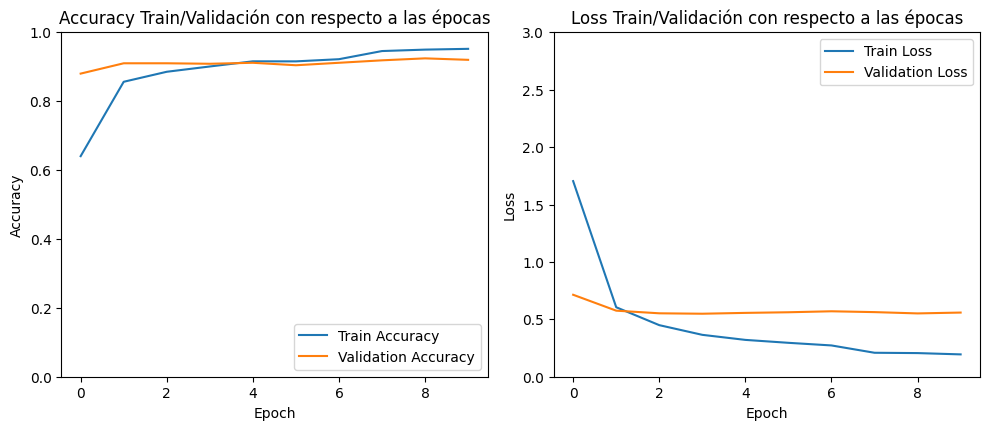

In [88]:
acc_loss_plot(base_history, 'base')

#### Fine-Tuning ResNet18

In [28]:
# Modelo fine-tuned (todas las capas entrenables)
ft_model = models.resnet18(pretrained=True)
ft_model.fc = nn.Linear(ft_model.fc.in_features, len(class_names))

for param in ft_model.parameters():
    param.requires_grad = True
ft_model = ft_model.to(device)

ft_criterion = nn.CrossEntropyLoss()
ft_optimizer = optim.Adam(ft_model.parameters(), lr=1e-4)
ft_scheduler = optim.lr_scheduler.StepLR(ft_optimizer, step_size=5, gamma=0.5)

In [29]:
# Entrenamiento del modelo fine-tuned
ft_model, ft_history = train_model(ft_model,
                         trainloader,
                         validloader,
                         ft_criterion,
                         ft_optimizer,
                         ft_scheduler,
                         num_epochs=5,
                         device=device,
                         save_path='models/ft_rn18_model.pth')

✅ Mejor modelo guardado
Epoch [1/5] - Loss: 1.6638 - Acc: 0.6703 - Val_Loss: 0.6342 - Val_Acc: 0.9014
✅ Mejor modelo guardado
Epoch [2/5] - Loss: 0.4830 - Acc: 0.9066 - Val_Loss: 0.4692 - Val_Acc: 0.9200
✅ Mejor modelo guardado
Epoch [3/5] - Loss: 0.2519 - Acc: 0.9519 - Val_Loss: 0.4598 - Val_Acc: 0.9214
✅ Mejor modelo guardado
Epoch [4/5] - Loss: 0.1370 - Acc: 0.9775 - Val_Loss: 0.4623 - Val_Acc: 0.9229
Epoch [5/5] - Loss: 0.0856 - Acc: 0.9884 - Val_Loss: 0.4442 - Val_Acc: 0.9229
Entrenamiento finalizado


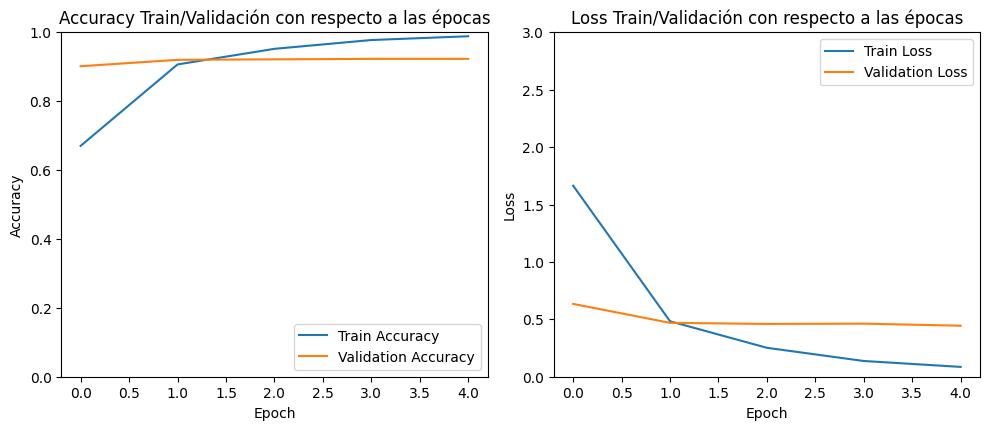

In [89]:
acc_loss_plot(ft_history, 'rn_ft')

### Modelo convolucional

In [31]:
class CustomCNN(nn.Module):
    def __init__(self, num_classes=70):
        super(CustomCNN, self).__init__()

        self.features = nn.Sequential(
            # Conv 1
            nn.Conv2d(3, 8, kernel_size=3, padding=1),  # 224x224
            nn.ReLU(),

            # Conv 2
            nn.Conv2d(8, 16, kernel_size=3, padding=1),  # 224x224
            nn.ReLU(),

            # Pool
            nn.MaxPool2d(kernel_size=2, stride=2),  # 112x112

            # Conv 3
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # 112x112
            nn.ReLU(),
            nn.MaxPool2d(2),  # 56x56

            # Conv 4
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # 56x56
            nn.ReLU(),
            nn.MaxPool2d(2)  # 28x28
        )

        # Global pooling + clasificación
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),  # Output: (batch, 64, 1, 1)
            nn.Flatten(),  # Output: (batch, 64)
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [32]:
cnn_model = CustomCNN(num_classes=70).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=0.0005, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

cnn_model, cnn_history = train_model(cnn_model, trainloader, validloader, criterion, optimizer,
                             scheduler, num_epochs=20, device=device,
                             save_path='models/custom_cnn.pth')

✅ Mejor modelo guardado
Epoch [1/20] - Loss: 4.2126 - Acc: 0.0240 - Val_Loss: 4.1125 - Val_Acc: 0.0286
✅ Mejor modelo guardado
Epoch [2/20] - Loss: 4.0718 - Acc: 0.0361 - Val_Loss: 3.9962 - Val_Acc: 0.0329
✅ Mejor modelo guardado
Epoch [3/20] - Loss: 4.0172 - Acc: 0.0422 - Val_Loss: 3.9625 - Val_Acc: 0.0557
✅ Mejor modelo guardado
Epoch [4/20] - Loss: 3.9865 - Acc: 0.0518 - Val_Loss: 3.9126 - Val_Acc: 0.0571
✅ Mejor modelo guardado
Epoch [5/20] - Loss: 3.9633 - Acc: 0.0510 - Val_Loss: 3.8879 - Val_Acc: 0.0686
Epoch [6/20] - Loss: 3.9277 - Acc: 0.0625 - Val_Loss: 3.8847 - Val_Acc: 0.0686
Epoch [7/20] - Loss: 3.9103 - Acc: 0.0618 - Val_Loss: 3.8411 - Val_Acc: 0.0643
Epoch [8/20] - Loss: 3.9060 - Acc: 0.0608 - Val_Loss: 3.8534 - Val_Acc: 0.0671
✅ Mejor modelo guardado
Epoch [9/20] - Loss: 3.8801 - Acc: 0.0668 - Val_Loss: 3.8154 - Val_Acc: 0.0857
Epoch [10/20] - Loss: 3.8677 - Acc: 0.0683 - Val_Loss: 3.7905 - Val_Acc: 0.0686
Epoch [11/20] - Loss: 3.8432 - Acc: 0.0743 - Val_Loss: 3.7785 - V

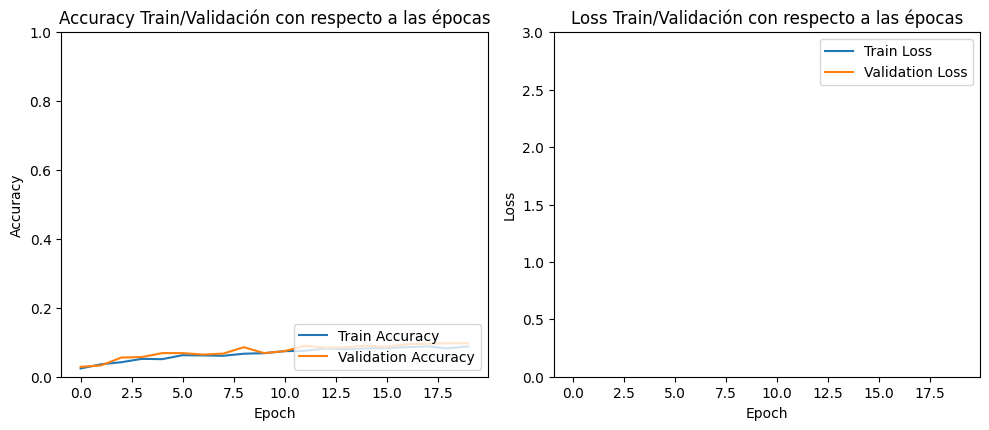

In [90]:
acc_loss_plot(cnn_history, 'cnn')

## Métricas y Predicciones obtenidas

In [34]:
# ==== Carga de Modelo existente ====
# base_model = models.resnet18(pretrained=False)
# base_model.fc = nn.Linear(base_model.fc.in_features, len(class_names))
# base_model.load_state_dict(torch.load("models/base_model.pth", map_location=device))
# base_model = base_model.to(device)
# base_model.eval()

_, true_labels_base, pred_labels_base = get_predictions(model=base_model, dataloader=testloader, device=device)

metrics_base = compute_metrics(
    y_true=true_labels_base,
    y_pred=pred_labels_base,
    labels=list(range(len(class_names))),
    average='macro'
)

In [35]:
#==== Carga de Modelo Fine-Tuned Existente ====
# ft_model = models.resnet18(pretrained=False)
# ft_model.fc = nn.Linear(ft_model.fc.in_features, len(class_names))
# ft_model.load_state_dict(torch.load("./models/ft_rn18_model.pth", map_location=device))
# ft_model = ft_model.to(device)
# ft_model.eval()

_, true_labels_ft, pred_labels_ft = get_predictions(model=ft_model, dataloader=testloader, device=device)

metrics_ft = compute_metrics(
    y_true=true_labels_ft,
    y_pred=pred_labels_ft,
    labels=list(range(len(class_names))),
    average='macro'
)

In [37]:
#==== Carga de Modelo Convolucional Existente ====
# cnn_model = models.resnet18(pretrained=False)
# ft_model.fc = nn.Linear(ft_model.fc.in_features, len(class_names))
# ft_model.load_state_dict(torch.load("./models/ft_rn18_model.pth", map_location=device))
# ft_model = ft_model.to(device)
# ft_model.eval()

_, true_labels_cnn, pred_labels_cnn = get_predictions(model=cnn_model, dataloader=testloader, device=device)

metrics_cnn = compute_metrics(
    y_true=true_labels_cnn,
    y_pred=pred_labels_cnn,
    labels=list(range(len(class_names))),
    average='macro'
)

### Matrices de confusión

In [38]:
plot_confusion_matrix(true_labels_cnn, pred_labels_cnn, classes=class_names, title="Matriz de Confusión - CNN")
plot_confusion_matrix(true_labels_base, pred_labels_base, classes = testloader.dataset.classes, title='Base ResNet18 - Matriz de Confusión')
plot_confusion_matrix(true_labels_ft, pred_labels_ft, classes=testset.classes, title='Fine-tuned ResNet18 - Matriz de Confusión')

Se obseva que ambos modelos de ResNet logran captar correctamente las carácterísticas de cada imagen y lograr una buena clasificación. En cambio, el modelo convolucional presenta algunas dificultades a la hora de reconocer ciertas clases

#### Métricas

In [39]:
metrics_df = pd.DataFrame([
    metrics_base,
    metrics_ft,
    metrics_cnn
], index=['ResNet18 Base', 'ResNet18 Fine-Tuned', 'CNN'])

metrics_df.to_csv("outputs/metricas_modelos.csv")

In [40]:
metrics_df.round(2)

,Exactitud (Accuracy),Precisión (Precision),Sensibilidad (Recall),F1 Score,Especificidad (avg)
ResNet18 Base,0.96,0.96,0.96,0.96,1.00
ResNet18 Fine-Tuned,0.96,0.97,0.96,0.96,1.00
CNN,0.11,0.07,0.11,0.07,0.99


Como era de esperarse, el modelo de ResNet18 con un fine-tunning realizado es el que logra el mejor rendimiento en general. El modelo de ResNet ofrese un desempeño sólido aunque levemente inferior, siendo este una buena alternativa cuando se busca reducir el tiempo de entrenamiento. Por otro lado, la CNN muestra un rendimiento pobre

## Interfaz de Gradio

Para la interfaz se dará la opción de elegir el modelo de CNN y ResNet18 fine-tunned dado que el logró mejores métricas que su verrsión base

In [41]:
rn_index, rn_image_paths, rn_image_labels = prepare_faiss_index(testloader, ft_model, device, class_names)

In [61]:
cnn_index, cnn_image_paths, cnn_image_labels = prepare_faiss_index(testloader, cnn_model, device, class_names)

In [43]:
def gradio_interface(img, model_selector):
    if model_selector == "CNN (Keras)":
        similar_images, predicted_breed = find_similar_images(img, cnn_model, cnn_index, cnn_image_paths, cnn_image_labels, device)
    elif model_selector == "ResNet18 Fine-Tuned (PyTorch)":
        similar_images, predicted_breed = find_similar_images(
            img,
            model=ft_model,
            index=rn_index,
            image_paths=rn_image_paths,
            image_labels=rn_image_labels,
            device=device
        )
    else:
        return [], "Modelo no reconocido", ""

    output_imgs = [plt.imread(path) for path, _, _ in similar_images]
    return output_imgs, predicted_breed, f"{model_selector} - búsqueda completada"

# --- Crear la interfaz ---
iface = gr.Interface(
    fn=gradio_interface,
    inputs=[
        gr.Image(type="pil", label="Sube una imagen de perro"),
        gr.Dropdown(choices=["CNN (Keras)", "ResNet18 Fine-Tuned (PyTorch)"], label="Selecciona el modelo")
    ],
    outputs=[
        gr.Gallery(label="Imágenes más similares", columns=5),
        gr.Textbox(label="Predicción de raza por mayoría"),
        gr.Textbox(label="Estado")
    ],
    title="Buscador de Similitud por Modelo",
    description="Sube una imagen de perro y elige qué modelo usar para encontrar imágenes similares."
)

iface.launch()

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://412edd12fb9bc12cd7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# **Etapa 3**: Pipeline de Detección y Clasificación en Escenas Complejas

Se usará YOLOv8 para la detección de objetos.

En una primera instancia, comienzo utilizando la versíon más básica del mismo y en caso de no lograr un buen desempeño iré usando versiones más complejas. Esto es para no utilizar recursos adicionales sin motivos suficientes

Una vez detectado el/los objeto/s, se pasará un recorte del mismo para ser clasificado por ResNet18 fine-tunned, dado que fue el modelo con mejores resultados

## Comparasión Nano - Small

In [44]:
yolon_model = YOLO("yolov8n-seg.pt")
yolosn_model = YOLO("yolov8s-seg.pt")

yolon_model.info()
yolosn_model.info()

100%|██████████| 6.74M/6.74M [00:00<00:00, 108MB/s]


100%|██████████| 22.8M/22.8M [00:00<00:00, 116MB/s] 


YOLOv8n-seg summary: 151 layers, 3,409,968 parameters, 0 gradients, 12.8 GFLOPs
YOLOv8s-seg summary: 151 layers, 11,821,056 parameters, 0 gradients, 42.9 GFLOPs


(151, 11821056, 0, 42.860595200000006)


0: 640x640 1 dog, 24.5ms
1: 640x640 6 dogs, 24.5ms
Speed: 11.9ms preprocess, 24.5ms inference, 83.1ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 dog, 22.2ms
1: 640x640 6 dogs, 22.2ms
Speed: 2.2ms preprocess, 22.2ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)


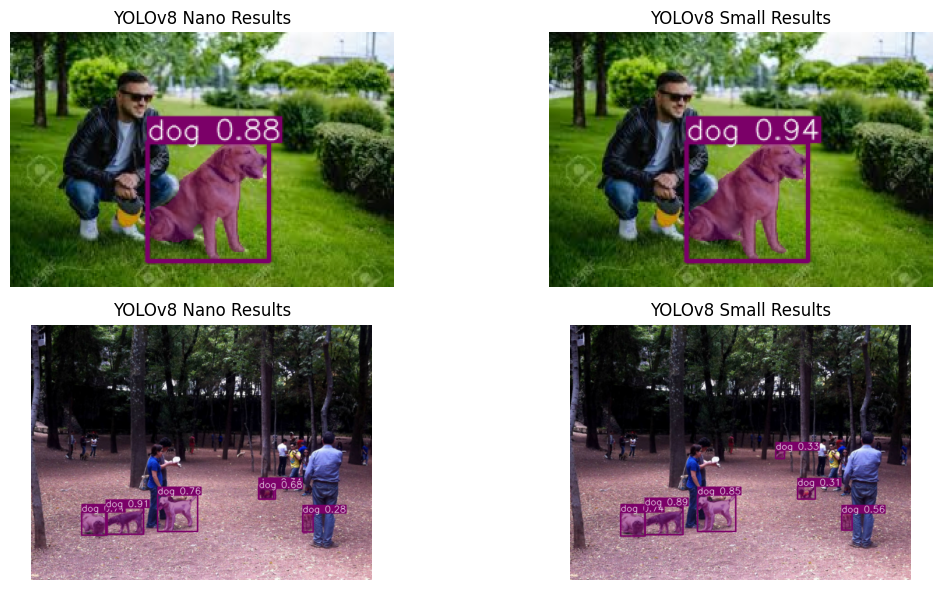

In [45]:
# Perform inference on a sample image
image_path = ["/content/data/test_yolo/test_yolo1.jpg", '/content/data/test_yolo/test_yolo2.jpg']

nano_results = yolon_model(image_path, save = False, project = 'outputs', name = 'yolo_nano_results', classes = [16])
small_results = yolosn_model(image_path, save= False, project = 'outputs', name = 'yolo_small_results' ,classes = [16])


# Crear una figura con dos subplots lado a lado
fig, axs = plt.subplots(2, 2, figsize=(12, 6))

for i in range(2):
    axs[i][0].imshow(nano_results[i].plot()[..., ::-1])  # BGR → RGB
    axs[i][0].set_title("YOLOv8 Nano Results")
    axs[i][0].axis('off')

    axs[i][1].imshow(small_results[i].plot()[..., ::-1])  # BGR → RGB
    axs[i][1].set_title("YOLOv8 Small Results")
    axs[i][1].axis('off')

plt.tight_layout()
plt.savefig('./outputs/plots/yolo_comparation')
plt.show()

## Definición de funciones necesarias

In [46]:
def get_crops_from_result(result, image):
    """
    Dado un resultado de YOLOv8 y la imagen original,
    devuelve una lista de recortes (PIL.Image) de cada detección.
    """
    boxes = result.boxes.xyxy.cpu().numpy().astype(int)  # coordenadas [x1, y1, x2, y2]
    crops = []
    for x1, y1, x2, y2 in boxes:
        crop = image.crop((x1, y1, x2, y2))  # recorte con PIL
        crops.append(crop)
    return crops

In [47]:
def yolo_inference(image, model):
    """
    Realiza inferencia con un modelo YOLOv8 sobre una imagen PIL.
    Devuelve coordenadas de las cajas y recortes (PIL).
    """
    results = model(image, classes = [16])

    # Obtener coordenadas de las cajas [x1, y1, x2, y2]
    boxes = results[0].boxes.xyxy.cpu().numpy().astype(int).tolist()
    crops = get_crops_from_result(results[0], image)

    return boxes, crops

In [48]:
def get_resnet18_prediction(crop, model, device, class_names):
    """
    Realiza una predicción de raza de perro usando un modelo ResNet18.

    Args:
        crop (PIL.Image): Recorte de la imagen del perro.
        model (nn.Module): Modelo ResNet18 cargado.
        device (torch.device): Dispositivo donde se ejecuta el modelo.
        class_names (list): Lista de nombres de clases.

    Returns:
        str: Nombre de la raza predicha.
    """
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img_tensor = transform(crop).unsqueeze(0).to(device)  # [1, 3, 224, 224]

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)

    _, predicted_idx = torch.max(output, 1)
    return class_names[predicted_idx.item()]

In [49]:
def detection_pipeline(image, model):
    """
    La función se encargará de realizar la todo el proceso de
    detección de perros con YOLOv8 y la clasificación de sus razas con ResNet18.

    Args:
        image (PIL.Image): Imagen PIL de la escena.
        model (YOLO): Modelo YOLOv8 para la detección de perros.

    Returns:
        image_with_boxes(PIL.Image): Imagen con los bounding boxes de cada perro detectado
        labeled_gallery_items (list): Lista de tuplas (recorte, raza predicha) para cada perro detectado.

    """

    # Paso 1: Detección con YOLO
    bboxes, crops = yolo_inference(image, model)

    # Dibujar los bounding boxes sobre una copia de la imagen original
    image_with_boxes = image.copy()
    draw = ImageDraw.Draw(image_with_boxes)
    for box in bboxes:
        draw.rectangle(box, outline="red", width=3)

    # Paso 2: Clasificación con ResNet18
    labeled_gallery_items = []
    for crop in crops:
        breed = get_resnet18_prediction(crop, ft_model, device, class_names)
        labeled_gallery_items.append((crop, breed))

    return image_with_boxes, labeled_gallery_items

### Interfaz de Gradio

In [50]:
# Gradio interface
iface = gr.Interface(
    fn=partial(detection_pipeline, model=yolosn_model),
    inputs=gr.Image(type="pil", label="Subí una imagen con perros"),
    outputs=[
        gr.Image(label="Imagen con detecciones"),
        gr.Gallery(label="Recortes", columns=5, object_fit="contain")
    ],
    title="Detector y Clasificador de Razas de Perros 🐶",
    description="Subí una imagen con uno o varios perros. La app detectará los perros con YOLOv8 y clasificará su raza con ResNet18."
)
iface.launch()


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a13935bbc610f0d1c5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# **Etapa 4**: Évaluación, Optimización y Herramientas de Anotación

In [51]:
def run_pipeline(image, model, classifier, device, class_names):
    """
    Ejecuta detección y clasificación sobre una imagen.
    Devuelve:
        - Lista de bounding boxes: [[x1, y1, x2, y2], ...]
        - Lista de labels predichas (índices enteros de class_names)
    """
    boxes, crops = yolo_inference(image, model)
    labels = []

    for crop in crops:
        breed = get_resnet18_prediction(crop, classifier, device, class_names)
        # class_idx = class_names.index(breed)
        labels.append(breed)

    return boxes, labels

In [52]:
def load_yolo_annotations(txt_path, image_size):
    boxes = []
    labels = []
    with open(txt_path, "r") as f:
        for line in f:
            cls, x_c, y_c, w, h = map(float, line.strip().split())
            x_c *= image_size[0]
            y_c *= image_size[1]
            w *= image_size[0]
            h *= image_size[1]
            x1 = x_c - w / 2
            y1 = y_c - h / 2
            x2 = x_c + w / 2
            y2 = y_c + h / 2
            boxes.append([x1, y1, x2, y2])
            labels.append(int(cls))
    return boxes, labels

In [53]:
from sklearn.metrics import precision_score, recall_score, f1_score

def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

In [54]:
def compute_map_05(y_true, y_pred, class_names):
    """
    Calcula el mAP@0.5 de forma simplificada.
    Considera TP si label predicho == label real y fue detectado (iou >= 0.5).
    """
    tp_per_class = defaultdict(int)
    fp_per_class = defaultdict(int)
    fn_per_class = defaultdict(int)

    for yt, yp in zip(y_true, y_pred):
        if yp == "NoDetectado":
            fn_per_class[yt] += 1
        elif yt == yp:
            tp_per_class[yt] += 1
        else:
            fp_per_class[yp] += 1
            fn_per_class[yt] += 1

    ap_per_class = {}
    for cls in class_names:
        tp = tp_per_class[cls]
        fp = fp_per_class[cls]
        fn = fn_per_class[cls]
        denom = tp + fp + fn
        ap = tp / denom if denom > 0 else 0
        ap_per_class[cls] = ap

    mAP = np.mean(list(ap_per_class.values()))
    return mAP, ap_per_class

In [60]:
ious_all = []
y_true = []
y_pred = []

# # Leer clases desde el archivo obj.names (una clase por línea)
with open("data/complex_images/obj.names") as f:
    class_names_complex = [line.strip() for line in f.readlines()]

with open("data/complex_images/train.txt") as f:

    for line in f:
        img_path = line.strip()
        img = Image.open(img_path)
        w, h = img.size
        gt_txt = img_path.replace(".jpg", ".txt").replace(".jfif", ".txt")

        gt_boxes, gt_labels = load_yolo_annotations(gt_txt, (w, h))

        pred_boxes, pred_labels = run_pipeline(img, yolosn_model, ft_model, device, class_names)

        matched_preds = set()

        for gt_box, gt_label in zip(gt_boxes, gt_labels):
            best_iou = 0
            best_idx = -1
            for i, pred_box in enumerate(pred_boxes):
                if i in matched_preds:
                    continue
                iou = compute_iou(gt_box, pred_box)
                if iou > best_iou:
                    best_iou = iou
                    best_idx = i
            if best_iou >= 0.5:
                ious_all.append(best_iou)
                y_true.append(class_names_complex[gt_label])
                y_pred.append(pred_labels[best_idx])
                matched_preds.add(best_idx)
            else:
                y_true.append(gt_label)
                y_pred.append("NoDetectado")




# Evaluación
import numpy as np
import warnings
warnings.filterwarnings("ignore")

mask = np.array(y_pred) != -1
print("="*10)
print("Resultados:")

for yt, yp in zip(y_true, y_pred):
    if yp == "NoDetectado":
        print(f"❌ No detectado — Real: {yt}")
    elif yp != yt:
        print(f"⚠️ Incorrecto — Real: {yt} | Predicho: {yp}")
    else:
        print(f"✅ Correcto — {yt}")


mAP, aps = compute_map_05(y_true, y_pred, class_names_complex)


print(f"\nmAP@0.5:   {mAP:.4f}")
print(f"IoU promedio: {np.mean(ious_all):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='macro'):.4f}")
print(f"Recall: {recall_score(y_true, y_pred, average='macro'):.4f}")
print(f"F1-score: {f1_score(y_true, y_pred, average='macro'):.4f}")
print("="*10)




0: 448x640 3 dogs, 17.5ms
Speed: 3.6ms preprocess, 17.5ms inference, 2.5ms postprocess per image at shape (1, 3, 448, 640)

0: 384x640 2 dogs, 14.5ms
Speed: 1.6ms preprocess, 14.5ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 dog, 13.9ms
Speed: 1.5ms preprocess, 13.9ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 dog, 13.9ms
Speed: 1.8ms preprocess, 13.9ms inference, 6.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 dogs, 13.3ms
Speed: 2.0ms preprocess, 13.3ms inference, 2.4ms postprocess per image at shape (1, 3, 384, 640)

0: 448x640 1 dog, 16.5ms
Speed: 2.1ms preprocess, 16.5ms inference, 2.2ms postprocess per image at shape (1, 3, 448, 640)

0: 640x448 (no detections), 15.6ms
Speed: 2.1ms preprocess, 15.6ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 448)

0: 384x640 3 dogs, 14.1ms
Speed: 1.5ms preprocess, 14.1ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0

## Optimización de Modelos

In [64]:
import torch
import os
from torch.quantization import quantize_dynamic


In [65]:
# Asumiendo que ft_model es tu modelo ResNet18 ya entrenado
model = ft_model.eval()  # Poner el modelo en modo evaluación

# Cuantizar dinámicamente los pesos de las capas lineales y convolucionales
quantized_model = quantize_dynamic(
    model,
    {torch.nn.Linear, torch.nn.Conv2d},  # Capas a cuantizar
    dtype=torch.qint8  # Precisión objetivo
)

# Guardar y verificar tamaño del modelo original
torch.save(model.state_dict(), 'temp_original.pth')
original_size = os.path.getsize('temp_original.pth')/1e6

# Guardar y verificar tamaño del modelo cuantizado
torch.save(quantized_model.state_dict(), 'temp_quantized.pth')
quantized_size = os.path.getsize('temp_quantized.pth')/1e6

# Mostrar resultados
print(f"Tamaño original del modelo: {original_size:.2f} MB")
print(f"Tamaño cuantizado del modelo: {quantized_size:.2f} MB")

Tamaño original del modelo: 44.93 MB
Tamaño cuantizado del modelo: 44.82 MB


In [81]:
import os
import time
from torch.quantization import quantize_dynamic
import torchvision
from torchvision import transforms

In [79]:
import torch
import os
import time
from torch.quantization import quantize_dynamic

# Crear la carpeta 'models' si no existe
os.makedirs('models', exist_ok=True)

# Configuración inicial
device = torch.device('cpu')  # La cuantización dinámica solo funciona en CPU
model = ft_model.to(device).eval()  # Mover modelo a CPU y modo evaluación

## 1. Cuantización Dinámica
quantized_model = quantize_dynamic(
    model,
    {torch.nn.Linear, torch.nn.Conv2d},
    dtype=torch.qint8
)

## 2. Guardar modelos en la carpeta 'models'
# Modelo original
original_path = os.path.join('models', 'resnet18_original.pth')
torch.save(model.state_dict(), original_path)

# Modelo cuantizado
quantized_path = os.path.join('models', 'resnet18_quantized.pth')
torch.save(quantized_model.state_dict(), quantized_path)

# Verificar tamaños
original_size = os.path.getsize(original_path)/1e6
quantized_size = os.path.getsize(quantized_path)/1e6

print(f"Tamaño original: {original_size:.2f} MB (guardado en {original_path})")
print(f"Tamaño cuantizado: {quantized_size:.2f} MB (guardado en {quantized_path})")

## 3. Medición de Tiempos de Inferencia (opcional)
input_tensor = torch.randn(1, 3, 224, 224).to(device)
num_runs = 100

# Calentamiento (warm-up)
with torch.no_grad():
    _ = model(input_tensor)
    _ = quantized_model(input_tensor)

# Medición modelo original
start = time.time()
with torch.no_grad():
    for _ in range(num_runs):
        _ = model(input_tensor)
original_time = time.time() - start

# Medición modelo cuantizado
start = time.time()
with torch.no_grad():
    for _ in range(num_runs):
        _ = quantized_model(input_tensor)
quantized_time = time.time() - start

print(f"\nTiempo original ({num_runs} ejecuciones): {original_time:.4f} segundos")
print(f"Tiempo cuantizado ({num_runs} ejecuciones): {quantized_time:.4f} segundos")
print(f"Speedup: {original_time/quantized_time:.2f}x")

Tamaño original: 44.93 MB (guardado en models/resnet18_original.pth)
Tamaño cuantizado: 44.82 MB (guardado en models/resnet18_quantized.pth)

Tiempo original (100 ejecuciones): 6.0080 segundos
Tiempo cuantizado (100 ejecuciones): 11.0135 segundos
Speedup: 0.55x


### Script de Anotación Automática

In [85]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- Función para autoanotación ---
def auto_annotate_folder(folder_path, detector, classifier, device, class_names, yolo_output_dir, coco_output_path):
    # Mover el clasificador al dispositivo (GPU/CPU)
    classifier = classifier.to(device).eval()

    # Crear directorios de salida
    os.makedirs(yolo_output_dir, exist_ok=True)
    os.makedirs(os.path.dirname(coco_output_path), exist_ok=True)

    # Estructura COCO
    coco_data = {
        "images": [],
        "annotations": [],
        "categories": [{"id": i, "name": name} for i, name in enumerate(class_names)],
    }
    annotation_id = 1
    image_id = 0

    # Procesar cada imagen
    for filename in tqdm(os.listdir(folder_path)):
        if not filename.lower().endswith(('jpg', 'jpeg', 'png')):
            continue

        path = os.path.join(folder_path, filename)
        image = Image.open(path).convert("RGB")
        width, height = image.size

        # Detección con YOLO
        boxes, crops = yolo_inference(image, detector)
        yolo_lines = []

        for i, box in enumerate(boxes):
            x1, y1, x2, y2 = box
            crop = crops[i]

            # Preprocesar y enviar al dispositivo
            crop_tensor = transform(crop).unsqueeze(0).to(device)

            # Predicción de clase
            with torch.no_grad():
                outputs = classifier(crop_tensor)
                _, pred = torch.max(outputs, 1)
                breed_name = class_names[pred.item()]

            breed_id = class_names.index(breed_name)

            # Formato YOLO (normalizado)
            xc = ((x1 + x2) / 2) / width
            yc = ((y1 + y2) / 2) / height
            w = (x2 - x1) / width
            h = (y2 - y1) / height
            yolo_lines.append(f"{breed_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}")

            # Formato COCO
            coco_data["annotations"].append({
                "id": annotation_id,
                "image_id": image_id,
                "category_id": breed_id,
                "bbox": [x1, y1, x2 - x1, y2 - y1],
                "area": (x2 - x1) * (y2 - y1),
                "iscrowd": 0,
            })
            annotation_id += 1

        # Guardar anotación YOLO
        yolo_filename = os.path.splitext(filename)[0] + ".txt"
        with open(os.path.join(yolo_output_dir, yolo_filename), "w") as f:
            f.write("\n".join(yolo_lines))

        # Añadir metadatos COCO
        coco_data["images"].append({
            "id": image_id,
            "file_name": filename,
            "width": width,
            "height": height,
        })
        image_id += 1

    # Guardar JSON COCO
    with open(coco_output_path, "w") as f:
        json.dump(coco_data, f, indent=4)

    print(f"\n✅ Anotaciones guardadas en:\n- YOLO: {yolo_output_dir}\n- COCO: {coco_output_path}")

# --- Configuración en Colab ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Cargar modelos
detector = YOLO("yolov8n.pt").to(device)
classifier = torch.hub.load('pytorch/vision', 'resnet18', pretrained=False)
classifier.fc = torch.nn.Linear(classifier.fc.in_features, len(class_names))  # Ajustar a tus clases
classifier.load_state_dict(torch.load("/content/models/ft_rn18_model.pth", map_location=device))

# Ejecutar
auto_annotate_folder(
    folder_path="/content/data/test_yolo",
    detector=detector,
    classifier=classifier,
    device=device,
    class_names= class_names,
    yolo_output_dir="/content/outputs/yolo",
    coco_output_path="/content/outputs/coco.json",
)

Using cache found in /root/.cache/torch/hub/pytorch_vision_main
  0%|          | 0/2 [00:00<?, ?it/s]


0: 480x640 4 dogs, 9.9ms
Speed: 3.1ms preprocess, 9.9ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


 50%|█████     | 1/2 [00:00<00:00,  6.58it/s]


0: 448x640 1 dog, 7.6ms
Speed: 1.9ms preprocess, 7.6ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)


100%|██████████| 2/2 [00:00<00:00, 11.25it/s]


✅ Anotaciones guardadas en:
- YOLO: /content/outputs/yolo
- COCO: /content/outputs/coco.json
